In [10]:
import pandas as pd 
import numpy as np

In [25]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import matplotlib.pyplot as plt

In [5]:
data=pd.read_csv("CarPrice_Assignment.csv")

In [6]:
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [7]:
data=data.drop(['CarName','car_ID'],axis=1)
data=pd.get_dummies(data,drop_first=True)

In [8]:
x=data.drop('price',axis=1)
y=data['price']

In [18]:
scaler=StandardScaler()
x=scaler.fit_transform(x)
y=scaler.fit_transform(np.array(y).reshape(-1,1))
print(x)
print(y)

[[ 1.74347043 -1.6907718  -0.42652147 ...  1.08666971 -0.21428571
  -0.070014  ]
 [ 1.74347043 -1.6907718  -0.42652147 ...  1.08666971 -0.21428571
  -0.070014  ]
 [ 0.133509   -0.70859588 -0.23151305 ...  1.08666971 -0.21428571
  -0.070014  ]
 ...
 [-1.47645244  1.72187336  1.19854871 ...  1.08666971 -0.21428571
  -0.070014  ]
 [-1.47645244  1.72187336  1.19854871 ... -0.92024282 -0.21428571
  -0.070014  ]
 [-1.47645244  1.72187336  1.19854871 ...  1.08666971 -0.21428571
  -0.070014  ]]
[[ 2.73911432e-02]
 [ 4.04461099e-01]
 [ 4.04461099e-01]
 [ 8.44849301e-02]
 [ 5.23667906e-01]
 [ 2.47610036e-01]
 [ 5.56292928e-01]
 [ 7.08124756e-01]
 [ 1.32988237e+00]
 [ 5.75010530e-01]
 [ 3.95677439e-01]
 [ 4.57790460e-01]
 [ 9.65360500e-01]
 [ 9.82300415e-01]
 [ 1.41646416e+00]
 [ 2.19381802e+00]
 [ 3.51826840e+00]
 [ 2.96176083e+00]
 [-1.01962107e+00]
 [-8.76070979e-01]
 [-8.40936341e-01]
 [-9.66793634e-01]
 [-8.65781550e-01]
 [-6.67521806e-01]
 [-8.84352716e-01]
 [-8.26255082e-01]
 [-7.11189142e

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)

In [19]:
sgd_model.fit(x_train,y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [22]:
y_pred=sgd_model.predict(x_test)

In [21]:
mse=mean_squared_error(y_test,y_pred)

In [27]:
print('Name: SR NIVEDHITHA')
print('Reg NO: 212225240102')

print(f"MSE: {mean_squared_error(y_test,y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test,y_pred):.2f}")
print(f"R^2: {r2_score(y_test,y_pred):.4f}")


Name: SR NIVEDHITHA
Reg NO: 212225240102
MSE: 0.21
MAE: 0.32
R^2: 0.8277


In [28]:
print("\nModel Coeffient")
print("Coefficient:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coeffient
Coefficient: [ 3.63285855e-02  1.03760151e-01  1.06447278e-02  1.77045598e-01
  1.77322650e-02  1.72475852e-01  2.85595951e-01 -2.72100014e-02
 -8.11702943e-02  1.74122415e-04  1.04390649e-01  3.73851529e-02
 -4.33380281e-02 -4.96316188e-02 -1.94786678e-02  1.80899592e-02
  2.04450565e-02 -1.62657347e-02 -8.70519982e-02 -1.58477409e-02
 -9.60863190e-02 -3.24439192e-02  6.44976390e-02  2.13245494e-01
  1.48219678e-02 -1.05236890e-01  7.26939407e-02 -1.38756532e-02
  3.36685336e-03  9.43080736e-03 -3.55598117e-02 -1.44835992e-01
 -7.83189931e-02  8.70528678e-04 -2.58320101e-02  9.43080736e-03
 -3.18581780e-03 -1.75496760e-02  1.94786678e-02 -1.81072166e-02
 -3.45429506e-02 -4.14259265e-02 -1.72640210e-02]
Intercept: [-0.01243858]


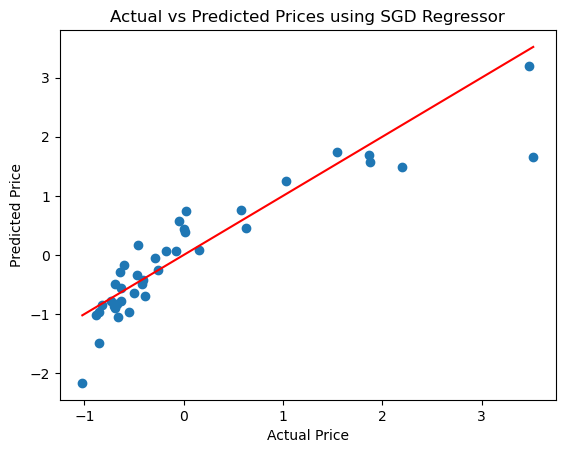

In [29]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red')
plt.show()